In [ ]:
import glob
import json
import logging
import sys
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold

console_handler = logging.StreamHandler(sys.stdout)
file_handler = logging.FileHandler("logs/anysleep_mnc_nt1_sfs.log", encoding="utf-8", mode="w")
formatter = logging.Formatter(
    "%(asctime)s [%(levelname)s] %(name)s: %(message)s",
    "%Y-%m-%d %H:%M:%S",
)
console_handler.setFormatter(formatter)
file_handler.setFormatter(formatter)
logging.basicConfig(
    level=logging.INFO,
    handlers=[console_handler, file_handler],
)
logger = logging.getLogger(__name__)


def calc_mode(data, axis=0):
    bins = np.apply_along_axis(
        lambda x: np.bincount(x, minlength=5), axis=axis, arr=data
    )
    # resolve ties randomly by adding a small random number to the counts
    rand_mat = np.random.random_sample(bins.shape)
    bins = bins + rand_mat
    return np.argmax(bins, axis=axis)


mnc_path = "../../examples/output/"
mnc_preds_glob = f"{mnc_path}/*/predictions*_c.npz"
mnc_preds_files = sorted(glob.glob(mnc_preds_glob))
print(mnc_preds_files)
# remove CAP
mnc_preds_files = [f for f in mnc_preds_files if f.split("/")[-2] != "CAP"]
print(mnc_preds_files)

keys_per_run_per_sr = {}
for pred_file in mnc_preds_files:
    f_handle = np.load(pred_file)
    keys = f_handle.files

    for k in keys:
        model_run = k.split("#")[1]
        sleep_stage_sr = int(k.split('#')[2])
        if model_run not in keys_per_run_per_sr:
            keys_per_run_per_sr[model_run] = {}
        if sleep_stage_sr not in keys_per_run_per_sr[model_run]:
            keys_per_run_per_sr[model_run][sleep_stage_sr] = []
        keys_per_run_per_sr[model_run][sleep_stage_sr].append([f_handle, k])

epoch_sr = 128 * 30
n_classes = 5
feature_block_duration = int(1.5 * 60 * 2)  # in epochs
possible_triplets = [f"{i}{j}{k}" for i in range(n_classes) for j in range(n_classes) for k in range(n_classes)
                     if i != j and j != k]


def calc_features(sleep_sr, preds_dict, preds_per_epoch):
    features = {}

    for rec in preds_dict.keys():
        preds = preds_dict[rec]

        sleep_start = np.where(preds_per_epoch[rec] != 0)[0][0]
        sleep_end = np.where(preds_per_epoch[rec] != 0)[0][-1]

        features[rec] = []
        for i in range(sleep_start, sleep_end, feature_block_duration):
            features[rec].append([0] * len(possible_triplets))
            features_block = preds[i * sleep_sr:min(i + feature_block_duration, sleep_end) * sleep_sr]
            features_block_1r = np.r_[features_block[0], features_block[:-1]]
            features_block_1l = np.r_[features_block[1:], features_block[-1]]

            # find triplets with a different element in the middle
            triplet_mask = np.where(((features_block - features_block_1r) != 0)
                                    & ((features_block - features_block_1l) != 0))[0]

            for trip_idx in triplet_mask:
                trip_str = f"{features_block[trip_idx - 1]}{features_block[trip_idx]}{features_block[trip_idx + 1]}"
                features[rec][-1][possible_triplets.index(trip_str)] += 1

    return features

In [ ]:
import pandas as pd

mapping = pd.read_excel("cohorts_deid.xlsx")
print(mapping[["ID", "Label"]].groupby("ID").count().sort_values("Label").tail(10))
print(mapping[["ID", "Label"]].groupby("ID").mean().sort_values("Label").tail(10))
mapping["ID"] = mapping["ID"].astype(str).str.upper()
diag_map = {
    "\'NON-NARCOLEPSY CONTROL\'": "Healthy",
    "\'T1 NARCOLEPSY\'": "NT1",
    "\'OTHER HYPERSOMNIA\'": "Other",
}
mapping["Diagnosis_short"] = mapping["Diagnosis"].apply(lambda x: diag_map[x] if x in diag_map else "Unknown")
mapping["is_N1"] = (mapping["Diagnosis_short"] == "NT1").astype(int)
subj_nt1_dict = mapping.query("Diagnosis_short != 'Other'")[["ID", "is_N1"]].set_index("ID")["is_N1"].to_dict()


def get_cohort(s_id):
    if s_id.upper() not in subj_nt1_dict:
        if s_id.upper().startswith("CHC"):
            coh = 0
        elif s_id.upper().startswith("CHP"):
            coh = 1
        else:
            coh = None
    else:
        coh = subj_nt1_dict[s_id.upper()]
    return coh

In [3]:
from sklearn.ensemble import RandomForestClassifier
from concurrent.futures import ProcessPoolExecutor
from sklearn.metrics import f1_score


def train_and_predict(features, train_recs, test_recs, n_exps):
    x_train = []
    y_train = []
    x_test = []
    y_test = []
    subject_mapping_train = []
    subject_mapping_test = []

    for subject_name, subj_features in features.items():
        lab = get_cohort(subject_name)
        if lab is None:
            print(f"Subject {subject_name} not found in subj_nt1_dict, skipping...")
            continue
        if subject_name in train_recs:
            x_train.extend(subj_features)
            y_train.extend([lab] * len(subj_features))
            subject_mapping_train.extend([subject_name] * len(subj_features))
        elif subject_name in test_recs:
            x_test.extend(subj_features)
            y_test.extend([lab] * len(subj_features))
            subject_mapping_test.extend([subject_name] * len(subj_features))
        else:
            raise ValueError(f"Subject {subject_name} not in train or test set")

    x_train = np.array(x_train)
    y_train = np.array(y_train)
    x_test = np.array(x_test)
    y_test = np.array(y_test)
    subject_mapping_train = np.array(subject_mapping_train)
    subject_mapping_test = np.array(subject_mapping_test)

    label_nt1 = []
    predict_nt1 = []
    selected_features = []
    sfs_scores = []
    for run_num in range(n_exps):
        y_pred, sel_feat, cv_scores = fit_and_predict(run_num, x_train, y_train, x_test, subject_mapping_train)

        y_test_subj = []
        y_pred_subj = []
        for subj in np.unique(subject_mapping_test):
            assert np.all(y_test[subject_mapping_test == subj] == y_test[subject_mapping_test == subj][0])
            y_test_subj.append(y_test[subject_mapping_test == subj][0])
            y_pred_subj.append(np.mean(y_pred[subject_mapping_test == subj]))

        label_nt1.append(y_test_subj)
        predict_nt1.append(y_pred_subj)
        selected_features.append(sel_feat)
        sfs_scores.append(cv_scores)

    return label_nt1, predict_nt1, selected_features, sfs_scores


with open("../high-freq/rnd_parameter_map_rndfcls.json", "r") as f:
    rnd_parameter_map = json.load(f)


def fit_and_predict(run_num, x_train, y_train, x_test, subject_mapping_train):
    clf = RandomForestClassifier(n_estimators=200, criterion="gini", class_weight="balanced",
                                 max_depth=rnd_parameter_map[run_num]["max_tree_depth"],
                                 min_samples_leaf=rnd_parameter_map[run_num]["min_samples_leaf"],
                                 min_samples_split=rnd_parameter_map[run_num]["min_samples_split"],
                                 max_features=rnd_parameter_map[run_num]["max_features"])

    n_features_to_select = 5
    selected_features_idcs = []
    scores = []
    for i in range(n_features_to_select):
        remain_feat = np.array(list(set(range(x_train.shape[1])) - set(selected_features_idcs)))

        with ProcessPoolExecutor(max_workers=32) as executor:
            partial_f = partial(sfs, x_train, y_train, clf, selected_features_idcs, subject_mapping_train)
            results = np.array(list(executor.map(partial_f, remain_feat)))
            best_score = max(results)
            best_feat = remain_feat[results == best_score]
            np.random.shuffle(best_feat)  # to avoid bias in selection
            best_feat = int(best_feat[0])  # take first if multiple features have same score
            logger.info(f"Previous features: {selected_features_idcs}, remaining features {remain_feat.tolist()}, "
                        f"scores {[f'{r:.4f}' for r in results]}, selected feature {best_feat}")

        selected_features_idcs = selected_features_idcs + [best_feat]
        scores.append(best_score)

    x_train_best_feat = x_train[:, selected_features_idcs]
    x_test_best_feat = x_test[:, selected_features_idcs]
    clf.fit(x_train_best_feat, y_train)
    y_pred = clf.predict(x_test_best_feat)

    return y_pred, selected_features_idcs, scores


def sfs(x_train, y_train, clf, previous_features, subject_mapping_train, current_feature):
    x_train_temp = x_train[:, previous_features + [current_feature]]

    subjects = np.unique(subject_mapping_train)
    subj_labels = np.array([y_train[subject_mapping_train == subj][0] for subj in subjects])
    skf = StratifiedKFold(n_splits=5, shuffle=True)
    folds = skf.split(subjects, subj_labels)
    scores = []
    for tr_subj, te_subj in folds:
        tr_subj_mask = np.isin(subject_mapping_train, subjects[tr_subj])
        te_subj_mask = np.isin(subject_mapping_train, subjects[te_subj])
        clf.fit(x_train_temp[tr_subj_mask], y_train[tr_subj_mask])
        y_pred = clf.predict(x_train_temp[te_subj_mask])

        y_pred_subj = []
        for subj in subjects[te_subj]:
            y_pred_subj.append(np.mean(y_pred[subject_mapping_train[te_subj_mask] == subj]))
        y_pred_subj = np.array(y_pred_subj)
        y_pred_subj_bin = (np.array(y_pred_subj) > 0.5).astype(int)
        y_pred_subj_bin[y_pred_subj == 0.5] = np.random.randint(0, 2, size=np.sum(y_pred_subj == 0.5))

        y_true_subj = subj_labels[te_subj]
        scores.append(f1_score(y_true_subj, y_pred_subj_bin, average="macro", zero_division=1))
    return np.mean(scores)

In [4]:
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

n_exps = 50
srs = [1, 128]

# data split
first_model_run = list(keys_per_run_per_sr.keys())[0]
all_rec_ids = []
all_cohs = []
for _, k in keys_per_run_per_sr[first_model_run][1]:
    s_id = k.split("#")[0]
    lab = get_cohort(s_id)
    if lab is not None:
        all_rec_ids.append(s_id)
        all_cohs.append(lab)
train_recs, test_recs = train_test_split(all_rec_ids, test_size=0.2, random_state=42, stratify=all_cohs, shuffle=True)
logger.info(train_recs)
logger.info(test_recs)

mf1_scores = {}
sfs_features = {}
sfs_scores = {}
for model_run, files_per_sr in keys_per_run_per_sr.items():
    logger.info(f"Model epoch: {model_run}")
    preds_per_epoch = {}
    for file in files_per_sr[1]:  # 1 = 30s epochs
        preds_per_epoch[file[1].split("#")[0]] = file[0][file[1]]
    mf1_scores[model_run] = {}
    sfs_features[model_run] = {}
    sfs_scores[model_run] = {}
    for sleep_stage_sr in srs:
        files = files_per_sr[sleep_stage_sr]
        preds_per_window_sr = {}
        for file in files:
            preds_per_window_sr[file[1].split("#")[0]] = file[0][file[1]]
        features = calc_features(sleep_stage_sr, preds_per_window_sr, preds_per_epoch)
        label_nt1, predict_nt1, sel_feat, feat_scores = train_and_predict(features, train_recs, test_recs, n_exps)

        predict_nt1 = np.array(predict_nt1)
        label_nt1 = np.array(label_nt1)
        sel_feat = np.array(sel_feat)
        feat_scores = np.array(feat_scores)  # shape: (n_exps, n_features)

        predict_nt1_bin = (predict_nt1 > 0.5).astype(int)
        predict_nt1_bin[predict_nt1 == 0.5] = np.random.randint(0, 2, size=np.sum(predict_nt1 == 0.5))

        f1_array = []
        for i_exp in range(n_exps):
            cm = confusion_matrix(label_nt1[i_exp], predict_nt1_bin[i_exp])
            print(cm)  # TODO remove this
            precs, recs, f1s, _ = precision_recall_fscore_support(label_nt1[i_exp], predict_nt1_bin[i_exp],
                                                                  average=None, zero_division=1)
            f1_array.append(np.mean(f1s))

        logger.info(f"{sleep_stage_sr} sleep stages per epoch")
        logger.info(f"Avg. Makro F1: {np.mean(f1_array)}")
        logger.info(f"Std. Makro F1: {np.std(f1_array)}")
        logger.info("")
        mf1_scores[model_run][sleep_stage_sr] = f1_array
        sfs_features[model_run][sleep_stage_sr] = sel_feat
        sfs_scores[model_run][sleep_stage_sr] = feat_scores

2026-03-23 10:21:14 [INFO] __main__: ['SSC_5110_1', 'SSC_4828_1', '22646panotte', '10829698_p69', '06543328', '171002G-A', 'SSC_5232_1', 'SSC_6032_1', '10796263_p77', 'SSC_5267_1', 'SSC_5243_1', 'CHC008', 'SSC_5095_1', '15545421', 'SSC_5387_1', 'SSC_6939_1', '21531ddnotte', '20021lgnotte', 'SSC_7423_1', 'SSC_5574_1', 'SSC_6097_1', 'N0044', 'CHC2-050', 'SSC_7337_1', '12185389_p217', '24189gdnotte', 'CHC033', 'SSC_5399_1', '11346976_p150', '15935070', '19706cenotte', 'CHC2-058', '150902E-A', 'SSC_6849_1', '090301BA', '170101D-A', 'SSC_5086_1', 'SSC_5185_1', '12537044', 'SSC_4741_1', 'CHC027', '22679rmnotte', 'SSC_4844_1', '160601C-A', '10800928_p88', 'SSC_6848_1', 'SSC_5502_1', 'SSC_5178_1', 'SSC_5444_1', '21347fgnotte', 'CHP025', 'SSC_5457_1', '12510251_p255', '23496smnotte', 'CHC2-011', 'SSC_6947_1', 'SSC_6853_1', 'SSC_7485_1', 'SSC_7444_1', '22123qanotte', 'SSC_6860_1', 'SSC_5117_1', '15470184', '10836226_p81', '11523620_p158', 'Sub84', '21445csnotte', 'SSC_6129_1', 'SSC_6118_1', '225

2026-03-23 10:21:14 [INFO] __main__: ['SSC_4689_1', 'CHC2-059', '160701H-A', '171001G-A', '160701D-A', '24003pgnotte', 'SSC_5193_1', 'SSC_5567_1', '170301B-A', '12821160_p287', 'SSC_5249_1', 'SSC_6856_1', '170301D-B', '19892ocnotte', 'SSC_5062_1', '120901f-a', 'SSC_5421_1', 'SSC_5487_1', 'CHP036', 'SSC_5210_1', 'CHC012', 'SSC_7401_1', '06331991_p360', 'SSC_5255_1', 'Sub143', '16282638', 'SSC_5105_1', 'CHC2-029', 'CHC2-036', 'CHP030', 'SSC_5337_1', 'CHC2-025', 'CHC009', '20805dlnotte', 'CHC2-019', 'SSC_4731_1', 'CHC2-024', '20502minotte', 'SSC_5561_1', 'CHC2-033', 'SSC_5383_1', '23330mmnotte', 'SSC_4833_1', 'SSC_5494_1', '24524monotte', 'CHP058', '151201A-A', 'CHP010', '151001F-A', 'SSC_6133_1', '170101E-B', 'CHP032', 'SSC_5970_1', 'SSC_5214_1', 'CHP019', 'SSC_5190_1', 'CHP006', 'SSC_5431_1', 'SSC_6179_1', 'SSC_5187_1', 'SSC_5150_1', 'SSC_5212_1', 'Sub144', 'SSC_5572_1', 'CHP055', '160701E-A', '11166407_p133', 'CHC2-051', 'SSC_6870_1', 'Sub58', 'CHC2-039', 'CHC2-053', 'SSC_6413_1', 'CHC

2026-03-23 10:21:14 [INFO] __main__: Model epoch: anysleep-run1


Subject Sub25 not found in subj_nt1_dict, skipping...
Subject Sub68 not found in subj_nt1_dict, skipping...
Subject Sub05 not found in subj_nt1_dict, skipping...
Subject Sub59 not found in subj_nt1_dict, skipping...
Subject Sub141 not found in subj_nt1_dict, skipping...
Subject Sub94 not found in subj_nt1_dict, skipping...
Subject Sub34 not found in subj_nt1_dict, skipping...
Subject Sub60 not found in subj_nt1_dict, skipping...
Subject Sub42 not found in subj_nt1_dict, skipping...
Subject Sub80 not found in subj_nt1_dict, skipping...
Subject Sub53 not found in subj_nt1_dict, skipping...
Subject Sub115 not found in subj_nt1_dict, skipping...
Subject Sub45 not found in subj_nt1_dict, skipping...
Subject Sub04 not found in subj_nt1_dict, skipping...
Subject Sub54 not found in subj_nt1_dict, skipping...
Subject Sub14 not found in subj_nt1_dict, skipping...
Subject Sub76 not found in subj_nt1_dict, skipping...
Subject Sub149 not found in subj_nt1_dict, skipping...
Subject Sub07 not found i

2026-03-23 10:21:18 [INFO] __main__: Previous features: [], remaining features [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79], scores ['0.4670', '0.5765', '0.3762', '0.4163', '0.4005', '0.3388', '0.3762', '0.3762', '0.3762', '0.3762', '0.3762', '0.3762', '0.4361', '0.3762', '0.3762', '0.3762', '0.5364', '0.2947', '0.3762', '0.3762', '0.3332', '0.4012', '0.3762', '0.3762', '0.3762', '0.3762', '0.3762', '0.3762', '0.3814', '0.3914', '0.3762', '0.3762', '0.5188', '0.3192', '0.3388', '0.3814', '0.3739', '0.3886', '0.3388', '0.3762', '0.3762', '0.3388', '0.3940', '0.3388', '0.3754', '0.3388', '0.3101', '0.3388', '0.2877', '0.3136', '0.3754', '0.3388', '0.3199', '0.3209', '0.3209', '0.3388', '0.3854', '0.2841', '0.3892', '0.3030', '

...

2026-03-23 12:29:04 [INFO] __main__: Previous features: [3, 75, 73, 74], remaining features [0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 76, 77, 78, 79], scores ['0.8247', '0.8338', '0.8359', '0.8461', '0.8286', '0.8391', '0.8314', '0.8450', '0.8324', '0.8476', '0.8280', '0.8413', '0.8282', '0.8392', '0.8315', '0.8334', '0.8297', '0.8281', '0.8235', '0.8285', '0.8138', '0.8388', '0.8299', '0.8417', '0.8252', '0.8419', '0.8346', '0.8314', '0.8421', '0.8285', '0.8239', '0.8462', '0.8301', '0.8437', '0.8380', '0.8288', '0.8353', '0.8436', '0.8304', '0.8282', '0.8357', '0.8242', '0.8150', '0.8431', '0.8202', '0.8356', '0.8347', '0.8332', '0.8318', '0.8267', '0.8331', '0.8265', '0.8326', '0.8438', '0.8284', '0.8272', '0.8284', '0.8278', '0.8278', '0.8348', '0.

[[71  8]
 [ 6 46]]
[[72  7]
 [ 5 47]]
[[75  4]
 [12 40]]
[[76  3]
 [10 42]]
[[73  6]
 [10 42]]
[[75  4]
 [ 7 45]]
[[70  9]
 [ 9 43]]
[[74  5]
 [ 9 43]]
[[75  4]
 [ 8 44]]
[[74  5]
 [10 42]]
[[72  7]
 [ 8 44]]
[[71  8]
 [ 7 45]]
[[72  7]
 [10 42]]
[[73  6]
 [10 42]]
[[72  7]
 [ 4 48]]
[[72  7]
 [ 7 45]]
[[71  8]
 [ 8 44]]
[[72  7]
 [ 8 44]]
[[74  5]
 [ 9 43]]
[[73  6]
 [ 4 48]]
[[73  6]
 [ 7 45]]
[[76  3]
 [ 6 46]]
[[73  6]
 [ 9 43]]
[[71  8]
 [11 41]]
[[74  5]
 [13 39]]
[[74  5]
 [10 42]]
[[71  8]
 [ 9 43]]
[[72  7]
 [ 8 44]]
[[74  5]
 [ 9 43]]
[[73  6]
 [12 40]]
[[75  4]
 [ 7 45]]
[[74  5]
 [ 8 44]]
[[72  7]
 [ 9 43]]
[[75  4]
 [ 7 45]]
[[74  5]
 [ 8 44]]
[[73  6]
 [ 8 44]]
[[75  4]
 [ 8 44]]
[[72  7]
 [ 9 43]]
[[76  3]
 [ 6 46]]
[[71  8]
 [11 41]]
[[76  3]
 [11 41]]
[[74  5]
 [ 9 43]]
[[71  8]
 [ 6 46]]
[[75  4]
 [10 42]]
[[70  9]
 [ 9 43]]
[[73  6]
 [ 6 46]]
[[72  7]
 [ 9 43]]
[[71  8]
 [ 7 45]]
[[71  8]
 [ 8 44]]
[[74  5]
 [ 9 43]]
2026-03-23 12:29:04 [INFO] __main__: 128 sleep sta

2026-03-23 12:29:04 [INFO] __main__: Avg. Makro F1: 0.8844627717409614


2026-03-23 12:29:04 [INFO] __main__: Std. Makro F1: 0.019474947805154335


2026-03-23 12:29:04 [INFO] __main__: 


In [5]:
logger.info(mf1_scores)
logger.info(sfs_features)
logger.info(sfs_scores)

2026-03-23 12:29:04 [INFO] __main__: {'anysleep-run1': {1: [np.float64(0.7533885542168675), np.float64(0.7390270548165285), np.float64(0.7230443974630021), np.float64(0.549618320610687), np.float64(0.705353126405758), np.float64(0.7250617283950618), np.float64(0.6988505747126437), np.float64(0.7298969072164949), np.float64(0.5724941724941726), np.float64(0.7019248508701802), np.float64(0.7291989664082688), np.float64(0.7291989664082688), np.float64(0.6953488372093023), np.float64(0.7362473209066702), np.float64(0.7091170323928945), np.float64(0.7291989664082688), np.float64(0.5413165266106443), np.float64(0.7160591133004925), np.float64(0.7221900906111431), np.float64(0.5789285714285715), np.float64(0.7082776611312591), np.float64(0.7483423188944661), np.float64(0.7228720756595322), np.float64(0.7022147171526921), np.float64(0.6748955067920586), np.float64(0.7249475090666158), np.float64(0.705353126405758), np.float64(0.7390270548165285), np.float64(0.5417444029850746), np.float64(0.74

2026-03-23 12:29:04 [INFO] __main__: {'anysleep-run1': {1: array([[67,  3, 36, 29, 39],
       [67,  3, 68, 28, 29],
       [67,  3, 36, 29, 28],
       [ 1, 12,  7, 19, 28],
       [67,  3, 71, 69, 66],
       [67, 71, 36,  3, 68],
       [ 1,  3, 67, 29, 35],
       [67, 71, 36, 40, 29],
       [ 1, 12, 46, 36, 55],
       [67,  3, 71, 36, 40],
       [67,  3, 29, 28, 12],
       [67,  3, 29, 30, 15],
       [ 1, 28,  3, 67, 29],
       [67,  3, 68, 40, 61],
       [67,  3, 68, 71, 12],
       [67, 71, 68, 36, 79],
       [ 1, 28, 12, 75, 47],
       [ 1,  3, 67, 29, 28],
       [67, 71, 36, 39, 40],
       [ 1, 12, 35, 28, 32],
       [ 1,  3, 67, 71, 76],
       [67,  3, 36, 29, 13],
       [67, 71, 36, 29, 23],
       [ 1,  3, 28, 67, 29],
       [67,  3, 71, 70, 31],
       [67,  3, 68, 28, 12],
       [67, 68, 71, 73, 36],
       [67, 71,  3, 46, 23],
       [ 1, 12, 40, 75, 29],
       [67, 36, 29, 71,  3],
       [ 1,  3, 28,  0, 64],
       [ 1,  3, 75, 74, 28],
       [67, 7

2026-03-23 12:29:04 [INFO] __main__: {'anysleep-run1': {1: array([[0.5795654 , 0.64417349, 0.68840743, 0.70696747, 0.72853464],
       [0.59319737, 0.6399249 , 0.67419447, 0.68818852, 0.70188256],
       [0.58893683, 0.64538788, 0.68880054, 0.6850121 , 0.70860453],
       [0.60128326, 0.6182319 , 0.63621025, 0.63702009, 0.640227  ],
       [0.5868782 , 0.63523261, 0.68525534, 0.67744872, 0.67744872],
       [0.57509311, 0.65066789, 0.6848144 , 0.70743073, 0.72660583],
       [0.57893193, 0.61246433, 0.63909837, 0.67494527, 0.69236999],
       [0.58849694, 0.64716544, 0.68284993, 0.70295007, 0.71222342],
       [0.58477536, 0.61453391, 0.63905507, 0.64578239, 0.64583789],
       [0.58079605, 0.63739235, 0.67800246, 0.70404238, 0.7168887 ],
       [0.59968466, 0.64044193, 0.68547238, 0.70646379, 0.71257902],
       [0.58516664, 0.6584141 , 0.69429925, 0.71188305, 0.71188305],
       [0.58366689, 0.61065557, 0.63338044, 0.67816824, 0.70556215],
       [0.59155636, 0.64220491, 0.67553554, 

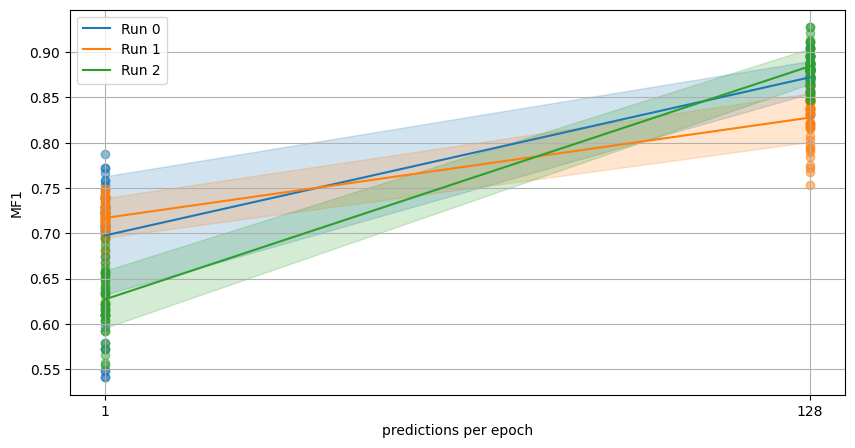

In [6]:
plt.figure(figsize=(10, 5))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]
for i, (model_run, mf1_scores_epoch) in enumerate(mf1_scores.items()):
    c = colors[i % len(colors)]
    means_to_plot = np.array(list(mf1_scores_epoch.values())).mean(axis=1)
    stds_to_plot = np.array(list(mf1_scores_epoch.values())).std(axis=1)
    plt.plot(range(len(mf1_scores_epoch)), means_to_plot, label=f"Run {i}", color=c)
    plt.fill_between(range(len(mf1_scores_epoch)), means_to_plot - stds_to_plot, means_to_plot + stds_to_plot,
                     alpha=0.2, color=c)
    plt.scatter(np.repeat(range(len(mf1_scores_epoch)), n_exps), np.array(list(mf1_scores_epoch.values())).flatten(),
                alpha=0.5, color=c)
first_key = next(iter(mf1_scores))
plt.xticks(range(len(mf1_scores[first_key])), list(mf1_scores[first_key].keys()))
plt.grid()
plt.xlabel("predictions per epoch")
plt.ylabel("MF1")
plt.legend()
plt.show()

In [1]:
import numpy as np

mf1_scores = {'anysleep-run1': {1: [0.7533885542168675, 0.7390270548165285, 0.7230443974630021, 0.549618320610687, 0.705353126405758, 0.7250617283950618, 0.6988505747126437, 0.7298969072164949, 0.5724941724941726, 0.7019248508701802, 0.7291989664082688, 0.7291989664082688, 0.6953488372093023, 0.7362473209066702, 0.7091170323928945, 0.7291989664082688, 0.5413165266106443, 0.7160591133004925, 0.7221900906111431, 0.5789285714285715, 0.7082776611312591, 0.7483423188944661, 0.7228720756595322, 0.7022147171526921, 0.6748955067920586, 0.7249475090666158, 0.705353126405758, 0.7390270548165285, 0.5417444029850746, 0.7412345679012347, 0.5962541488857278, 0.572294776119403, 0.7022147171526921, 0.7160591133004925, 0.7591911764705883, 0.7082776611312591, 0.7663735317631142, 0.7122739018087856, 0.7065704330512693, 0.7291989664082688, 0.7091170323928945, 0.7390270548165285, 0.7717770034843205, 0.5486715328467153, 0.7880786460925834, 0.7717770034843205, 0.7091170323928945, 0.7574074074074073, 0.7192310190296811, 0.6101190476190477], 128: [0.8657220379861321, 0.8800146546986627, 0.872444011684518, 0.864907491659084, 0.8800146546986627, 0.8574020319303338, 0.8308222126560483, 0.8640166086584844, 0.8815194452818812, 0.8815194452818812, 0.8515005071296462, 0.8808007279344858, 0.8966939642098878, 0.8630465531025152, 0.8821730527073215, 0.8695868591338975, 0.8369835739173719, 0.8952708935489821, 0.8630465531025152, 0.8320205165781278, 0.8821730527073215, 0.8827635582602471, 0.9043330087633885, 0.8715686274509804, 0.8206819313091089, 0.8808007279344858, 0.9054834054834054, 0.8706172839506172, 0.8952708935489821, 0.873977873977874, 0.8800146546986627, 0.8671320326949465, 0.8952708935489821, 0.8715686274509804, 0.8732462506047411, 0.8564995131450828, 0.864907491659084, 0.8883885102239533, 0.8732462506047411, 0.8469343828792817, 0.8715686274509804, 0.8555147058823529, 0.8800146546986627, 0.8815194452818812, 0.8715686274509804, 0.873977873977874, 0.8782301543037739, 0.8883885102239533, 0.896012700738841, 0.8589712918660286]}, 'anysleep-run2': {1: [0.7249475090666158, 0.7221900906111431, 0.7291989664082688, 0.6953488372093023, 0.7122739018087856, 0.7179584599797366, 0.7390270548165285, 0.6816420361247948, 0.6784237726098191, 0.7160591133004925, 0.7416173570019724, 0.6670679507758159, 0.7135270228053733, 0.7291989664082688, 0.7022147171526921, 0.7440277340056729, 0.6251678832116788, 0.7091170323928945, 0.7179584599797366, 0.7122739018087856, 0.7416173570019724, 0.7160591133004925, 0.7487212276214834, 0.7122739018087856, 0.6953488372093023, 0.7461240310077519, 0.7221900906111431, 0.7249475090666158, 0.7082776611312591, 0.6913912633775325, 0.7221900906111431, 0.7192310190296811, 0.7487212276214834, 0.7221900906111431, 0.7221900906111431, 0.7390270548165285, 0.7192310190296811, 0.69846547314578, 0.7345491388044579, 0.7221900906111431, 0.7152173913043478, 0.7262277951933125, 0.7291989664082688, 0.7319693094629156, 0.7082776611312591, 0.7135270228053733, 0.705353126405758, 0.7416173570019724, 0.7192310190296811, 0.7291989664082688], 128: [0.8532852165256346, 0.8369835739173719, 0.7752450980392156, 0.8160224705379495, 0.8469343828792817, 0.8394607843137255, 0.8444860980943456, 0.8382716049382717, 0.8206819313091089, 0.8630465531025152, 0.8172277828328784, 0.8073529411764706, 0.8469343828792817, 0.8355923694779116, 0.8331210191082803, 0.8369835739173719, 0.8340932117527862, 0.7532636227836591, 0.8444860980943456, 0.8191516064257028, 0.7677304964539007, 0.8800146546986627, 0.8147100424328146, 0.8320205165781278, 0.8382716049382717, 0.7970502571729565, 0.8175025329280649, 0.8382716049382717, 0.7717770034843205, 0.8220987654320988, 0.8480185626183061, 0.8480185626183061, 0.7843211752786221, 0.845758195451447, 0.8469343828792817, 0.8480185626183061, 0.8564995131450828, 0.7897530864197531, 0.8234068627450981, 0.802710843373494, 0.8469343828792817, 0.8444860980943456, 0.8532852165256346, 0.8444860980943456, 0.8308222126560483, 0.8630465531025152, 0.845758195451447, 0.7940251572327044, 0.7927215189873418, 0.8369835739173719]}, 'anysleep-run3': {1: [0.634149509644736, 0.6041208791208791, 0.6737564784276773, 0.5922467458970005, 0.6561216934778219, 0.6094850948509485, 0.6561216934778219, 0.6581043956043956, 0.6045630045630046, 0.668182113398714, 0.6221153846153846, 0.6094850948509485, 0.6221153846153846, 0.5727332028701891, 0.6384869085279665, 0.5786549707602339, 0.6415982693898327, 0.6627371273712737, 0.5660843021367798, 0.6166387959866221, 0.6144997324772605, 0.6581043956043956, 0.601916783543712, 0.6449864498644986, 0.6166387959866221, 0.6320224719101124, 0.6157833708478275, 0.5922467458970005, 0.651524452629425, 0.6107809847198642, 0.6191860465116279, 0.634149509644736, 0.6561216934778219, 0.6401098901098901, 0.6211683053788317, 0.6538054968287526, 0.6208521235781113, 0.6816420361247948, 0.6233467510063255, 0.6952475905616484, 0.6872655344110224, 0.5573327325974318, 0.6482097186700767, 0.6336539117386263, 0.6094850948509485, 0.6094850948509485, 0.555152224824356, 0.6350050658561297, 0.6495452113429642, 0.6094850948509485], 128: [0.8890904692791486, 0.9049346879535559, 0.8684738955823293, 0.8935957513277102, 0.8706172839506172, 0.9113830637722158, 0.8564995131450828, 0.8867901234567901, 0.902962962962963, 0.8782301543037739, 0.8800146546986627, 0.8808007279344858, 0.8630465531025152, 0.8706172839506172, 0.9131142598733796, 0.8883885102239533, 0.872444011684518, 0.8800146546986627, 0.8867901234567901, 0.9207789066279632, 0.896012700738841, 0.9274952339954492, 0.8791587233257487, 0.8469343828792817, 0.8520331325301205, 0.8782301543037739, 0.8640166086584844, 0.8800146546986627, 0.8867901234567901, 0.8532852165256346, 0.9113830637722158, 0.8952708935489821, 0.8715686274509804, 0.9113830637722158, 0.8952708935489821, 0.8876225490196079, 0.902962962962963, 0.8715686274509804, 0.9274952339954492, 0.8469343828792817, 0.8849146586345381, 0.8867901234567901, 0.8890904692791486, 0.8858885017421603, 0.8564995131450828, 0.9043330087633885, 0.8715686274509804, 0.8808007279344858, 0.872444011684518, 0.8867901234567901]}}

mean_scores = {}
for k, v in mf1_scores.items():
    for sr, f1 in v.items():
        if sr not in mean_scores:
            mean_scores[sr] = []
        mean_scores[sr].extend(f1)
mean_scores = {k: np.mean(v) for k, v in mean_scores.items()}
mean_scores

{1: np.float64(0.6807176950352767), 128: np.float64(0.8614756700064867)}